In [1]:
import os
import numpy as np
import random
import cv2
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d

import glob
from pathlib import Path
import sys
from tqdm import tqdm
import warnings
from functools import partial
warnings.filterwarnings('ignore')

# Add current directory to path for imports
sys.path.append('.')
sys.path.append('visualization')

from visualization.models_mae import mae_vit_large_patch16


# Set up ImageNet normalization constants
imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])

# Configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cpu


In [2]:
from slowfast.datasets.decoder import pyav_decode, temporal_sampling
from util.decoder.utils import tensor_normalize, spatial_sampling
import av
import torchvision.transforms as transforms

MEAN = (0.45, 0.45, 0.45)
STD = (0.225, 0.225, 0.225)
DEMO_PATH = 'CRIB/train_images/cat/0'

def prepare_video(path):
    video_container = av.open(path)
    frames, _, _ = pyav_decode(
        video_container,
        4,
        16,
        5,
        num_clips_uniform=10,
        target_fps=30,
        use_offset=False,
    )
    print(frames.shape)
    frames = temporal_sampling(frames, 0, 64, 16)
    print(frames.shape)
    frames = tensor_normalize(
        frames, 
        torch.tensor(MEAN), 
        torch.tensor(STD),
    ).permute(3, 0, 1, 2)
    print(frames.shape)
    frames = spatial_sampling(
        frames,
        spatial_idx=1,
        min_scale=256,
        max_scale=256,
        crop_size=224,
        random_horizontal_flip=False,
        inverse_uniform_sampling=False,
        aspect_ratio=None,
        scale=None,
        motion_shift=False,
    )
    print(frames.shape)
    return frames

def prepare_frames(path):
    frame_files = [f for f in os.listdir(path) if f.endswith('.png')]
    frame_files.sort(key=lambda x: int(x.split('.')[0]))  # Sort by numeric value
    
    # Load all frames
    frames_list = []
    for frame_file in frame_files:
        frame_path = os.path.join(path, frame_file)
        frame = Image.open(frame_path).convert('RGB')
        frame_array = np.array(frame)  # Shape: (H, W, 3)
        frames_list.append(frame_array)
    
    # Stack frames into tensor: (num_frames, H, W, 3)
    frames = torch.tensor(np.stack(frames_list), dtype=torch.float32)
    frames = frames / 255.0
    print(frames.shape)
    frames = temporal_sampling(frames, 0, 64, 16)
    print(frames.shape)
    frames = tensor_normalize(
        frames, 
        torch.tensor(MEAN), 
        torch.tensor(STD),
    ).permute(3, 0, 1, 2)
    print(frames.shape)
    frames = spatial_sampling(
        frames,
        spatial_idx=1,
        min_scale=256,
        max_scale=256,
        crop_size=224,
        random_horizontal_flip=False,
        inverse_uniform_sampling=False,
        aspect_ratio=None,
        scale=None,
        motion_shift=False,
    )
    print(frames.shape)
    return frames


def plot_input(tensor,ncols=None):
    tensor = tensor.float()
    if ncols is None:
        ncols = tensor.shape[1]
        nskip = 1
    else:
        ncols = np.minimum(ncols,tensor.shape[1])
        nskip = int(tensor.shape[1]/ncols)
    f, ax = plt.subplots(nrows=tensor.shape[0], ncols=ncols, figsize=(50, 20))

    tensor = tensor * torch.tensor(STD).view(3, 1, 1)
    tensor = tensor + torch.tensor(MEAN).view(3, 1, 1)
    tensor = torch.clip(tensor * 255, 0, 255).int()

    for i in range(tensor.shape[0]):
        for j in range(ncols):
            ax[i][j].axis("off")
            ax[i][j].imshow(tensor[i][j*nskip].permute(1, 2, 0))
    plt.show()

# vid = prepare_video(DEMO_PATH) # if a avi file
vid = prepare_frames(DEMO_PATH) # if a folder with frames

torch.Size([100, 200, 200, 3])
torch.Size([16, 200, 200, 3])
torch.Size([3, 16, 200, 200])
torch.Size([3, 16, 224, 224])


In [3]:
model = mae_vit_large_patch16(decoder_embed_dim=512, decoder_depth=4, mask_type="st", t_patch_size=2)

img_size (224, 224) patch_size (16, 16) frames 16 t_patch_size 2
==== num_patches 1568
model initialized


In [4]:
# !wget 'https://dl.fbaipublicfiles.com/video-mae-100x4-joint.pth' -O checkpoint.pth


In [5]:
checkpoint = torch.load("./checkpoint.pth", map_location='cpu', weights_only=False)
msg = model.load_state_dict(checkpoint['model'], strict=False)
print(msg)

<All keys matched successfully>


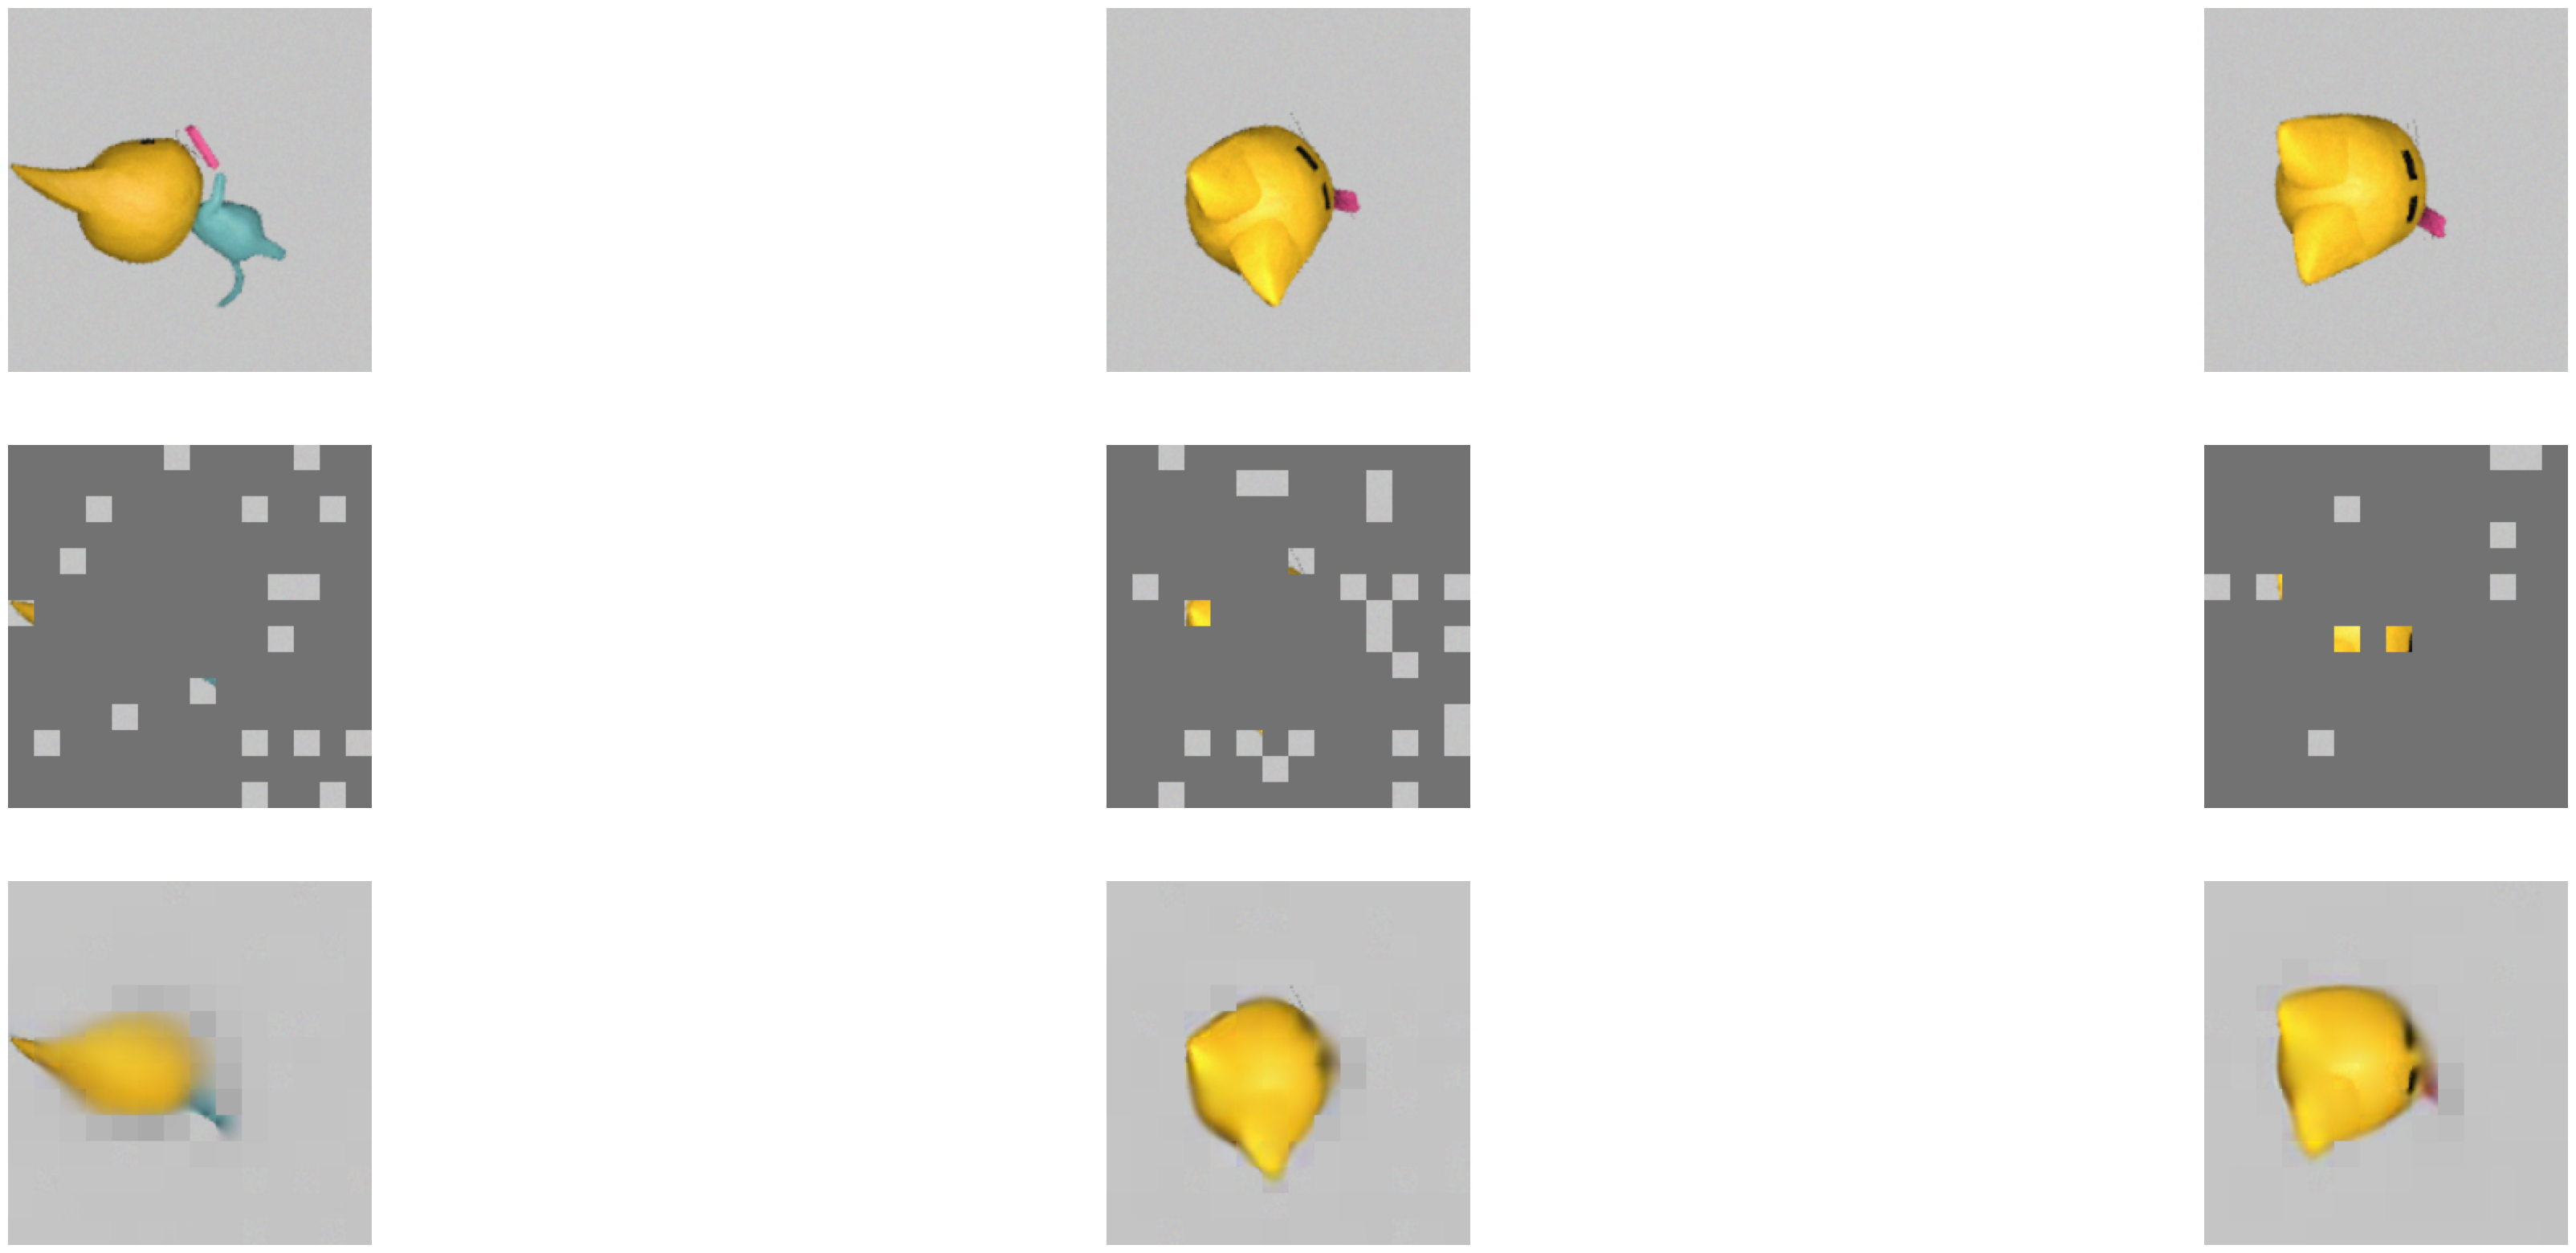

In [6]:
_, _, _, vis = model(vid.unsqueeze(0), 1, mask_ratio=0.9, visualize=True)
plot_input(vis[0].permute(0, 2, 1, 3, 4), ncols=3)

In [7]:

def generate_random_trajectory(num_frames, smoothing_factor=0.5, image_size=(224, 224), 
                             movement_scale=1.0, seed=None):
    """
    Generate a smooth random trajectory for video frames.
    
    Args:
        num_frames: Number of frames/points in the trajectory
        smoothing_factor: Float between 0-1, higher values = smoother trajectory
        image_size: Tuple of (width, height) for image bounds
        movement_scale: Scale factor for movement magnitude (1.0 = normal, 0.5 = slower, 2.0 = faster)
        seed: Optional random seed for reproducibility
    
    Returns:
        trajectory: List of (x, y) tuples, one per frame
    """
    
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
    
    width, height = image_size
    
    if num_frames <= 0:
        return []
    
    if num_frames == 1:
        return [(width // 2, height // 2)]
    
    # Method 1: Smooth random walk with Gaussian filtering
    def smooth_random_walk():
        # Generate random starting position (avoid edges)
        margin = min(width, height) // 8
        start_x = np.random.randint(margin, width - margin)
        start_y = np.random.randint(margin, height - margin)
        
        # Generate random increments
        base_step_size = min(width, height) * 0.02 * movement_scale
        
        # Create random steps with varying magnitudes
        steps_x = np.random.normal(0, base_step_size, num_frames - 1)
        steps_y = np.random.normal(0, base_step_size, num_frames - 1)
        
        # Apply smoothing to the steps
        sigma = smoothing_factor * 3.0 + 0.5
        steps_x = gaussian_filter(steps_x, sigma=sigma)
        steps_y = gaussian_filter(steps_y, sigma=sigma)
        
        # Compute cumulative positions
        x_positions = np.cumsum(np.concatenate([[start_x], steps_x]))
        y_positions = np.cumsum(np.concatenate([[start_y], steps_y]))
        
        return x_positions, y_positions
    
    # Method 2: Sine wave combination for more organic movement
    def sine_wave_trajectory():
        # Generate base path using sine waves
        t = np.linspace(0, 4 * np.pi, num_frames)
        
        # Multiple sine waves with different frequencies
        freq1 = 0.3 + np.random.random() * 0.7
        freq2 = 0.5 + np.random.random() * 1.0
        freq3 = 1.0 + np.random.random() * 2.0
        
        # Random phase shifts
        phase_x1 = np.random.random() * 2 * np.pi
        phase_x2 = np.random.random() * 2 * np.pi
        phase_y1 = np.random.random() * 2 * np.pi
        phase_y2 = np.random.random() * 2 * np.pi
        
        # Combine sine waves
        x_base = (np.sin(t * freq1 + phase_x1) * 0.4 + 
                 np.sin(t * freq2 + phase_x2) * 0.3 + 
                 np.sin(t * freq3) * 0.2)
        
        y_base = (np.cos(t * freq1 + phase_y1) * 0.4 + 
                 np.cos(t * freq2 + phase_y2) * 0.3 + 
                 np.cos(t * freq3) * 0.2)
        
        # Scale to image dimensions
        x_range = width * 0.6 * movement_scale
        y_range = height * 0.6 * movement_scale
        
        x_positions = width // 2 + x_base * x_range
        y_positions = height // 2 + y_base * y_range
        
        return x_positions, y_positions
    
    # Method 3: Perlin noise-like trajectory
    def perlin_like_trajectory():
        # Generate keyframes at lower resolution
        keyframe_density = max(1, num_frames // 10)
        num_keyframes = num_frames // keyframe_density + 1
        
        # Random keyframes
        keyframe_x = np.random.uniform(width * 0.2, width * 0.8, num_keyframes)
        keyframe_y = np.random.uniform(height * 0.2, height * 0.8, num_keyframes)
        
        # Interpolate between keyframes
        keyframe_indices = np.linspace(0, num_frames - 1, num_keyframes)
        frame_indices = np.arange(num_frames)
        
        interp_x = interp1d(keyframe_indices, keyframe_x, kind='cubic')
        interp_y = interp1d(keyframe_indices, keyframe_y, kind='cubic')
        
        x_positions = interp_x(frame_indices)
        y_positions = interp_y(frame_indices)
        
        # Add some noise
        noise_scale = min(width, height) * 0.01 * movement_scale
        x_positions += np.random.normal(0, noise_scale, num_frames)
        y_positions += np.random.normal(0, noise_scale, num_frames)
        
        return x_positions, y_positions
    
    # Choose method based on smoothing factor
    if smoothing_factor < 0.3:
        x_positions, y_positions = smooth_random_walk()
    elif smoothing_factor < 0.7:
        x_positions, y_positions = sine_wave_trajectory()
    else:
        x_positions, y_positions = perlin_like_trajectory()
    
    # Apply additional smoothing based on smoothing_factor
    if smoothing_factor > 0.1:
        sigma = smoothing_factor * 2.0
        x_positions = gaussian_filter(x_positions, sigma=sigma)
        y_positions = gaussian_filter(y_positions, sigma=sigma)
    
    # Ensure positions stay within bounds with soft boundaries
    margin = 10
    x_positions = np.clip(x_positions, margin, width - margin)
    y_positions = np.clip(y_positions, margin, height - margin)
    
    # Apply boundary repulsion to avoid edges
    boundary_force = 0.1 * movement_scale
    
    # Repel from left/right edges
    left_force = boundary_force / (x_positions + 1e-6)
    right_force = -boundary_force / (width - x_positions + 1e-6)
    x_positions += left_force + right_force
    
    # Repel from top/bottom edges
    top_force = boundary_force / (y_positions + 1e-6)
    bottom_force = -boundary_force / (height - y_positions + 1e-6)
    y_positions += top_force + bottom_force
    
    # Final clipping
    x_positions = np.clip(x_positions, 0, width - 1)
    y_positions = np.clip(y_positions, 0, height - 1)
    
    # Convert to integer coordinates
    trajectory = [(int(x), int(y)) for x, y in zip(x_positions, y_positions)]
    
    return trajectory


def create_trajectory_mask(trajectory, img_shape, patch_size, region_type='single', region_size=1):
    """
    Create masks for trajectory-based temporal masking
    
    Args:
        trajectory: List of (x, y) pixel coordinates, one per frame
        img_shape: (H, W) of each frame
        patch_size: Size of each patch
        region_type: Type of region to unmask ('single', 'square', 'circle', 'cross')
        region_size: Size of the region in patches (radius for circle, half-width for square/cross)
    
    Returns:
        masks: List of binary masks, one per frame, where 1=visible, 0=masked
    """
    C, T, H, W = img_shape
    masks = []
    
    for t in range(T):
        # Start with all patches masked (0)
        mask = torch.zeros(H, W)
        
        # Get trajectory point for this frame
        x_t, y_t = trajectory[t]
        
        # Find which patch this pixel belongs to (center patch)
        center_patch_x = (x_t // patch_size) * patch_size
        center_patch_y = (y_t // patch_size) * patch_size
        
        if region_type == 'single':
            # Original behavior - just one patch
            mask[center_patch_y:center_patch_y+patch_size, 
                 center_patch_x:center_patch_x+patch_size] = 1
                 
        elif region_type == 'square':
            # Square region of patches
            for dy in range(-region_size, region_size + 1):
                for dx in range(-region_size, region_size + 1):
                    patch_x = center_patch_x + dx * patch_size
                    patch_y = center_patch_y + dy * patch_size
                    
                    # Check bounds
                    if (0 <= patch_x < W - patch_size + 1 and 
                        0 <= patch_y < H - patch_size + 1):
                        mask[patch_y:patch_y+patch_size, 
                             patch_x:patch_x+patch_size] = 1
                             
        elif region_type == 'circle':
            # Circular region of patches
            for dy in range(-region_size, region_size + 1):
                for dx in range(-region_size, region_size + 1):
                    # Check if patch is within circular radius
                    distance = np.sqrt(dx**2 + dy**2)
                    if distance <= region_size:
                        patch_x = center_patch_x + dx * patch_size
                        patch_y = center_patch_y + dy * patch_size
                        
                        # Check bounds
                        if (0 <= patch_x < W - patch_size + 1 and 
                            0 <= patch_y < H - patch_size + 1):
                            mask[patch_y:patch_y+patch_size, 
                                 patch_x:patch_x+patch_size] = 1
                                 
        elif region_type == 'cross':
            # Cross-shaped region of patches
            # Horizontal line
            for dx in range(-region_size, region_size + 1):
                patch_x = center_patch_x + dx * patch_size
                patch_y = center_patch_y
                
                if (0 <= patch_x < W - patch_size + 1 and 
                    0 <= patch_y < H - patch_size + 1):
                    mask[patch_y:patch_y+patch_size, 
                         patch_x:patch_x+patch_size] = 1
            
            # Vertical line
            for dy in range(-region_size, region_size + 1):
                patch_x = center_patch_x
                patch_y = center_patch_y + dy * patch_size
                
                if (0 <= patch_x < W - patch_size + 1 and 
                    0 <= patch_y < H - patch_size + 1):
                    mask[patch_y:patch_y+patch_size, 
                         patch_x:patch_x+patch_size] = 1
                         
        elif region_type == 'diamond':
            # Diamond-shaped region of patches
            for dy in range(-region_size, region_size + 1):
                for dx in range(-region_size, region_size + 1):
                    # Manhattan distance for diamond shape
                    if abs(dx) + abs(dy) <= region_size:
                        patch_x = center_patch_x + dx * patch_size
                        patch_y = center_patch_y + dy * patch_size
                        
                        # Check bounds
                        if (0 <= patch_x < W - patch_size + 1 and 
                            0 <= patch_y < H - patch_size + 1):
                            mask[patch_y:patch_y+patch_size, 
                                 patch_x:patch_x+patch_size] = 1
        else:
            raise ValueError(f"Unknown region_type: {region_type}")

        mask = 1-mask # flipped compared to last codebase I used
        masks.append(mask)
    
    return masks
 

In [8]:
patch_size = model.patch_embed.patch_size[0]
trajectory = generate_random_trajectory(
    num_frames=vid.shape[1], 
    smoothing_factor=0.8,  # Very smooth
    movement_scale=0.5,    # Slower movement
    seed=2              
)

trajectory_masks = create_trajectory_mask(trajectory, vid.shape, patch_size,
                                          region_type='circle',region_size=2)
# np.array(trajectory_masks)

torch.Size([1, 1568])


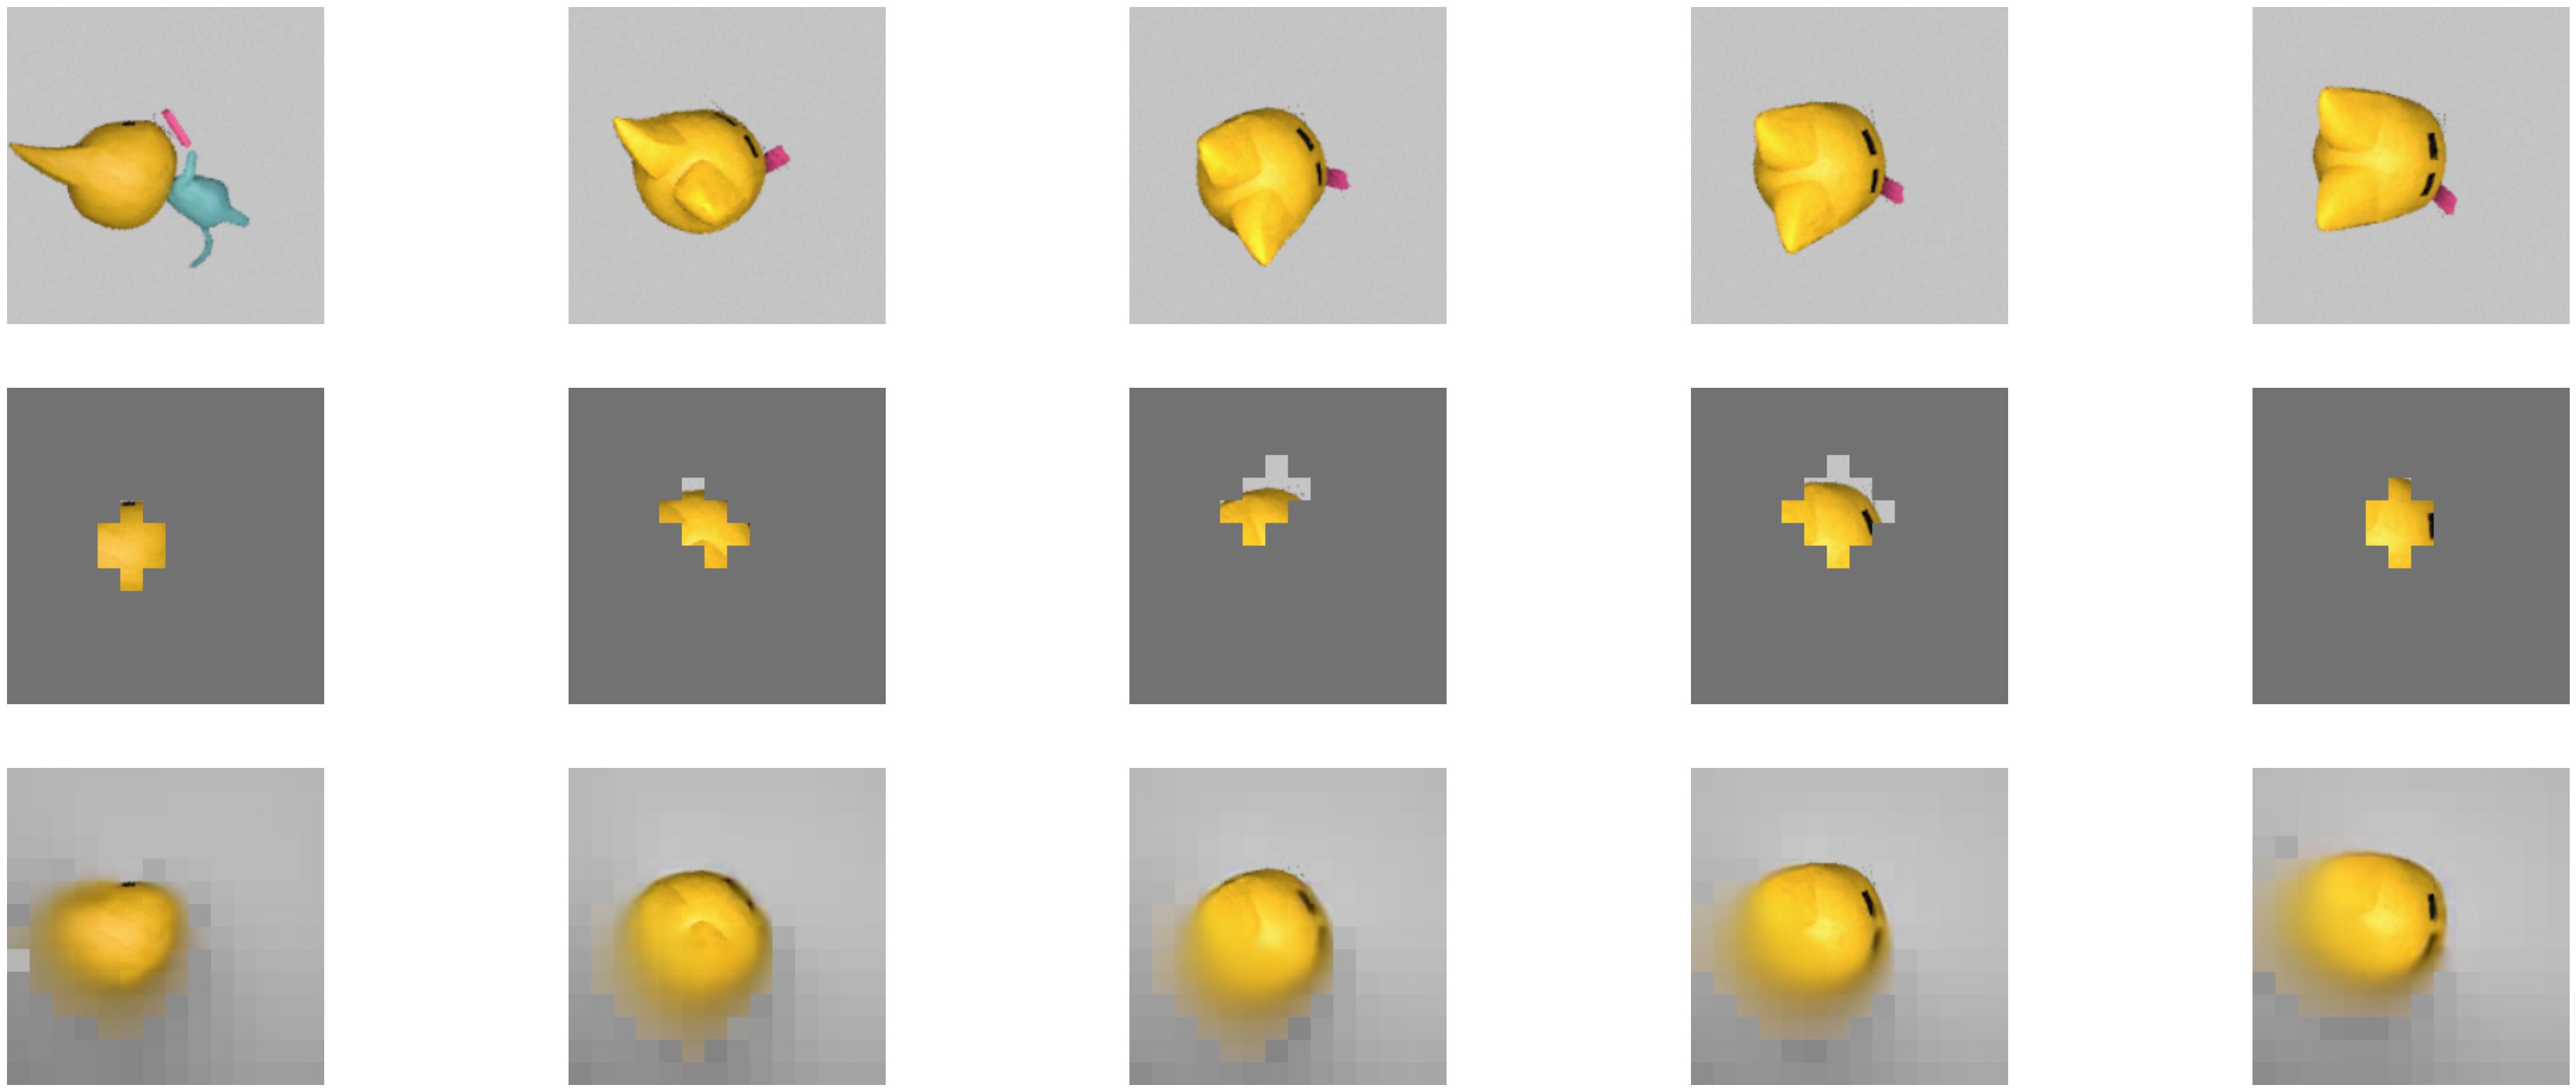

In [9]:
custom_mask = torch.tensor(np.array(trajectory_masks)).unsqueeze(0)
_, _, _, vis = model(vid.unsqueeze(0), 1, mask_ratio=0.9, visualize=True, custom_mask=custom_mask)
plot_input(vis[0].permute(0, 2, 1, 3, 4), ncols=5)

In [ ]:
vis[0].permute(0, 2, 1, 3, 4)

In [22]:

from matplotlib.animation import FuncAnimation, PillowWriter

def plot_animation(tensor, save_path="animation.gif", fps=8, dpi=100,
                   col_titles=("Input", "Masked", "Decoded")):
    """
    tensor:  (3, T, 3, H, W) in pixel space (0..255 or 0..1)
             output[0] -> input, output[1] -> masked, output[2] -> decoded
    save_path: where to write the GIF
    fps: frames per second of the GIF
    dpi: figure dpi
    col_titles: titles for the three panels
    """

    assert tensor.ndim == 5 and tensor.shape[0] == 3, \
        f"Expected output shape (3, T, 3, H, W), got {tuple(tensor.shape)}"

    _, T, C, H, W = tensor.shape
    assert C == 3, "Expected 3 channels (RGB)"

    # Convert to uint8 in [0,255] for imshow if needed
    if tensor.dtype != int:
        tensor = tensor * torch.tensor(STD).view(3, 1, 1) 
        tensor = tensor + torch.tensor(MEAN).view(3, 1, 1) 
        tensor = torch.clip(tensor * 255, 0, 255).int()
    tensor = tensor.detach().cpu().numpy()
    
    # Helper to get an (H,W,3) frame for a given column idx (0..2) and t (0..T-1)
    def frame(col_idx, t):
        # (3, H, W) -> (H, W, 3)
        return np.transpose(tensor[col_idx, t], (1, 2, 0))

    # ---- build figure ----
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=dpi, constrained_layout=True)
    for ax, title in zip(axes, col_titles):
        ax.set_title(title)
        ax.axis("off")

    # initialize images with t=0
    ims = []
    for i in range(3):
        im = axes[i].imshow(frame(i, 0), animated=True)
        ims.append(im)

    # ---- animation update ----
    def update(t):
        for i in range(3):
            ims[i].set_data(frame(i, t))
        return ims

    anim = FuncAnimation(fig, update, frames=T, interval=1000.0 / fps, blit=True)

    # ---- save as GIF ----
    writer = PillowWriter(fps=fps)
    anim.save(save_path, writer=writer)

    plt.close(fig)  # close to avoid duplicate display in notebooks
    return save_path



In [23]:
output=vis[0].permute(0, 2, 1, 3, 4)

gif_path = plot_animation(output, save_path="reconstruction.gif", fps=8)
